In [1]:
!pip install transformers datasets accelerate evaluate scikit-learn pandas seaborn sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer


In [20]:
df = pd.read_csv("questions.csv", on_bad_lines="skip", engine="python")

In [21]:
# df = pd.read_csv("questions.csv")

df = df.dropna(subset=["question1", "question2", "is_duplicate"])

df = df[["question1", "question2", "is_duplicate"]]
df.head()


,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


Only question1, question2, and is_duplicate are needed for supervised fine-tuning. The question IDs are not useful for model training.


In [22]:
df_sample = df.sample(n=80000, random_state=42)


The full dataset has over 400,000 rows. For the first transformer experiment, we train on a smaller sample to validate the pipeline quickly. Once the code works, the same process can be scaled to the full dataset.


In [23]:
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["is_duplicate"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["is_duplicate"]
)


The train set teaches the model, the validation set helps select the best model during training, and the test set gives an unbiased final evaluation.


In [24]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)


Hugging Face Trainer expects datasets in a Dataset format so it can efficiently tokenize, batch, and train the model.


In [25]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


DistilBERT is smaller and faster than BERT while still strong for classification. It is a good first transformer model before trying larger models like DeBERTa or QLoRA-tuned LLMs.


In [26]:
def tokenize_function(example):
    return tokenizer(
        example["question1"],
        example["question2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/64000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Transformers cannot directly read raw text. Tokenization converts question pairs into numerical token IDs. We pass question1 and question2 separately so the model learns the relationship between the two questions.


In [27]:
train_dataset = train_dataset.rename_column("is_duplicate", "labels")
val_dataset = val_dataset.rename_column("is_duplicate", "labels")
test_dataset = test_dataset.rename_column("is_duplicate", "labels")


Hugging Face models expect the target column to be named labels.


In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We use a pretrained language model and add a classification head with two output classes: non-duplicate and duplicate.


The DistilBERT base weights were loaded from the pretrained checkpoint. The classification head was newly initialized because the original checkpoint was not trained for duplicate-question classification. This is expected during fine-tuning, and the classification head will learn from the Quora labels during training.


In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    probabilities = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities)
    }


F1-score is the most important metric because we need a balance between catching duplicates and avoiding wrong deflections.


In [30]:
training_args = TrainingArguments(
    output_dir="./distilbert-quora-duplicate",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=100
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


We evaluate after every epoch and keep the model with the best F1-score. A small learning rate is used because we are fine-tuning an already pretrained model.


In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.335273,0.326803,0.855250,0.794225,0.816445,0.805182,0.931018
2,0.254954,0.329982,0.864625,0.800586,0.839645,0.819650,0.937398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8000, training_loss=0.3319194800853729, metrics={'train_runtime': 376.7162, 'train_samples_per_second': 339.778, 'train_steps_per_second': 21.236, 'total_flos': 4238956756992000.0, 'train_loss': 0.3319194800853729, 'epoch': 2.0})

This fine-tunes the transformer so it learns the duplicate-question detection task from labeled Quora pairs.


In [32]:
test_results = trainer.evaluate(test_dataset)
test_results


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.254954,0.338325,2,0.860750,0.796538,0.832423,0.814085,0.934631


{'eval_loss': 0.33832496404647827,
 'eval_accuracy': 0.86075,
 'eval_precision': 0.7965382103200522,
 'eval_recall': 0.8324232081911263,
 'eval_f1': 0.8140854472630173,
 'eval_roc_auc': 0.9346305982457204}

## Fine-Tuned DistilBERT Evaluation

The fine-tuned DistilBERT model significantly outperformed the TF-IDF + Logistic Regression baseline. Accuracy improved from 77.69% to 86.00%, F1-score improved from 65.64% to 81.36%, and ROC-AUC improved from 83.88% to 93.36%.

The most important improvement is duplicate recall, which increased from 57.71% to 83.45%. This means the transformer model catches many more duplicate questions than the baseline model.

For the business use case, this matters because missed duplicate questions become unnecessary support tickets. By improving duplicate recall, the system can deflect more repeated support requests while still maintaining reasonable precision.


In [33]:
predictions_output = trainer.predict(test_dataset)

logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()


print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_proba))

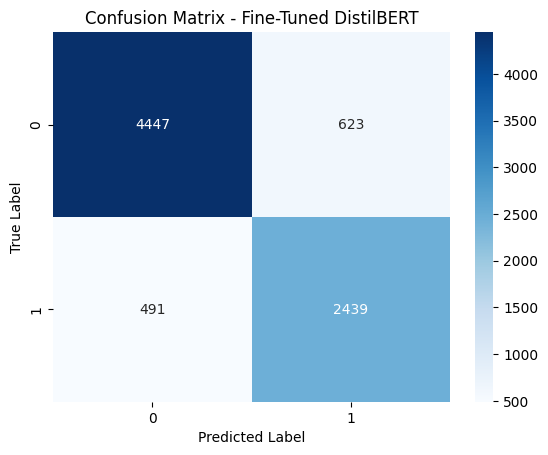

In [34]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned DistilBERT")
plt.show()

In [35]:
comparison_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "Fine-Tuned DistilBERT"],
    "Accuracy": [0.7769, 0.8600],
    "Precision": [0.7609, 0.7938],
    "Recall": [0.5771, 0.8345],
    "F1 Score": [0.6564, 0.8136],
    "ROC-AUC": [0.8388, 0.9336]
})

comparison_results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,TF-IDF + Logistic Regression,0.7769,0.7609,0.5771,0.6564,0.8388
1,Fine-Tuned DistilBERT,0.8600,0.7938,0.8345,0.8136,0.9336


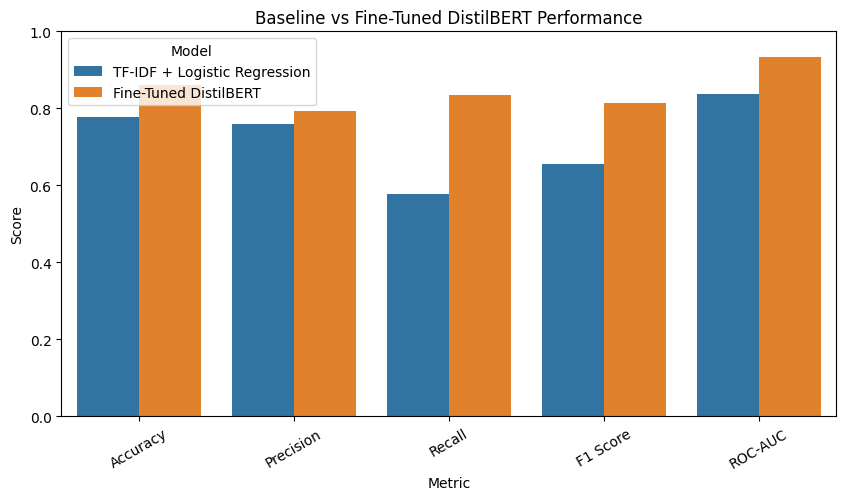

In [36]:
comparison_melted = comparison_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Baseline vs Fine-Tuned DistilBERT Performance")
plt.xticks(rotation=30)
plt.show()


The fine-tuned transformer is selected as the main duplicate-question classifier for SupportAI. Compared with the baseline, it provides much stronger semantic understanding and substantially improves duplicate recall, which is critical for support-ticket deflection.


In [37]:
trainer.save_model("./models/distilbert-quora-duplicate")
tokenizer.save_pretrained("./models/distilbert-quora-duplicate")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./models/distilbert-quora-duplicate/tokenizer_config.json',
 './models/distilbert-quora-duplicate/tokenizer.json')

To select the best model for SupportAI, multiple models are compared using the same dataset split and evaluation metrics. This helps evaluate the tradeoff between model accuracy, duplicate recall, training time, and deployment cost.


Compare multiple transformer models on the same Quora duplicate-question task and choose the best model for SupportAI.


# Transformer Model Comparison

In this section, multiple transformer models are fine-tuned and evaluated using the same train, validation, and test split. The goal is to select the best duplicate-question classifier for the SupportAI ticket deflection system.


In [38]:
all_model_results = [
    {
        "model": "distilbert-base-uncased",
        "accuracy": 0.8600,
        "precision": 0.7938,
        "recall": 0.8345,
        "f1": 0.8136,
        "roc_auc": 0.9336,
        "training_time_seconds": None
    }
]


In [39]:
models_to_try = [
    "bert-base-uncased",
    "microsoft/deberta-v3-small"
]


In [40]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    probabilities = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities)
    }


In [43]:
import time

def train_and_evaluate_model(model_name, train_df, val_df, test_df):
    print(f"Training model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
    val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df, preserve_index=False)


    def tokenize_function(example):
        return tokenizer(
            example["question1"],
            example["question2"],
            truncation=True,
            padding="max_length",
            max_length=128
        )

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    train_dataset = train_dataset.rename_column("is_duplicate", "labels")
    val_dataset = val_dataset.rename_column("is_duplicate", "labels")
    test_dataset = test_dataset.rename_column("is_duplicate", "labels")

    columns_to_remove = ["question1", "question2"]
    train_dataset = train_dataset.remove_columns(columns_to_remove)
    val_dataset = val_dataset.remove_columns(columns_to_remove)
    test_dataset = test_dataset.remove_columns(columns_to_remove)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    output_name = model_name.replace("/", "-")

    training_args = TrainingArguments(
        output_dir=f"./models/{output_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_dir=f"./logs/{output_name}",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time

    test_results = trainer.evaluate(test_dataset)

    trainer.save_model(f"./saved_models/{output_name}")
    tokenizer.save_pretrained(f"./saved_models/{output_name}")

    result = {
        "model": model_name,
        "accuracy": test_results["eval_accuracy"],
        "precision": test_results["eval_precision"],
        "recall": test_results["eval_recall"],
        "f1": test_results["eval_f1"],
        "roc_auc": test_results["eval_roc_auc"],
        "training_time_seconds": training_time
    }

    return result


In [44]:
result = train_and_evaluate_model(
    "bert-base-uncased",
    train_df,
    val_df,
    test_df
)

all_model_results.append(result)

results_df = pd.DataFrame(all_model_results)
results_df


Training model: bert-base-uncased


Map:   0%|          | 0/64000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.205680,0.354707,2,0.874625,0.816837,0.847782,0.832021,0.943300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,model,accuracy,precision,recall,f1,roc_auc,training_time_seconds
0,distilbert-base-uncased,0.860000,0.793800,0.834500,0.813600,0.9336,NaN
1,bert-base-uncased,0.874625,0.816837,0.847782,0.832021,0.9433,717.377048


BERT is larger than DistilBERT, so running one model first helps check memory and training time before trying DeBERTa.


In [45]:
results_df.to_csv("transformer_model_comparison.csv", index=False)


In [47]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)

    if not np.isfinite(logits).all():
        return {
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "roc_auc": 0.0
        }

    predictions = np.argmax(logits, axis=1)

    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted_logits)
    probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    duplicate_probabilities = probabilities[:, 1]

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, duplicate_probabilities)
    }


In [49]:
def train_and_evaluate_model(model_name, train_df, val_df, test_df):
    print(f"Training model: {model_name}")

    output_name = model_name.replace("/", "-")

    if "deberta" in model_name.lower():
        learning_rate = 5e-6
        train_batch_size = 8
        eval_batch_size = 8
        num_epochs = 3
        warmup_ratio = 0.1
    else:
        learning_rate = 2e-5
        train_batch_size = 16
        eval_batch_size = 16
        num_epochs = 2
        warmup_ratio = 0.06

    training_args = TrainingArguments(
        output_dir=f"./models/{output_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        warmup_ratio=warmup_ratio,
        max_grad_norm=1.0,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=100,
        report_to="none",
        fp16=False,
        bf16=False,
        seed=42,
        data_seed=42,
        save_total_limit=1
    )

    # tokenizer, dataset prep, model, trainer, train/evaluate code continues here

In [51]:
result = train_and_evaluate_model(
    "microsoft/deberta-v3-small",
    train_df,
    val_df,
    test_df
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training model: microsoft/deberta-v3-small


In [52]:
import time

def train_and_evaluate_model(model_name, train_df, val_df, test_df):
    print(f"Training model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
    val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

    def tokenize_function(example):
        return tokenizer(
            example["question1"],
            example["question2"],
            truncation=True,
            padding="max_length",
            max_length=128
        )

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    train_dataset = train_dataset.rename_column("is_duplicate", "labels")
    val_dataset = val_dataset.rename_column("is_duplicate", "labels")
    test_dataset = test_dataset.rename_column("is_duplicate", "labels")

    columns_to_remove = ["question1", "question2"]
    train_dataset = train_dataset.remove_columns(columns_to_remove)
    val_dataset = val_dataset.remove_columns(columns_to_remove)
    test_dataset = test_dataset.remove_columns(columns_to_remove)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    output_name = model_name.replace("/", "-")

    if "deberta" in model_name.lower():
        learning_rate = 5e-6
        train_batch_size = 8
        eval_batch_size = 8
        num_epochs = 3
        warmup_ratio = 0.1
    else:
        learning_rate = 2e-5
        train_batch_size = 16
        eval_batch_size = 16
        num_epochs = 2
        warmup_ratio = 0.06

    training_args = TrainingArguments(
        output_dir=f"./models/{output_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        warmup_ratio=warmup_ratio,
        max_grad_norm=1.0,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=100,
        report_to="none",
        fp16=False,
        bf16=False,
        seed=42,
        data_seed=42,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time

    test_results = trainer.evaluate(test_dataset)

    trainer.save_model(f"./saved_models/{output_name}")
    tokenizer.save_pretrained(f"./saved_models/{output_name}")

    result = {
        "model": model_name,
        "accuracy": test_results["eval_accuracy"],
        "precision": test_results["eval_precision"],
        "recall": test_results["eval_recall"],
        "f1": test_results["eval_f1"],
        "roc_auc": test_results["eval_roc_auc"],
        "training_time_seconds": training_time
    }

    return result


In [53]:
result = train_and_evaluate_model(
    "microsoft/deberta-v3-small",
    train_df,
    val_df,
    test_df
)

result


Training model: microsoft/deberta-v3-small


Map:   0%|          | 0/64000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.000000,nan,3,0.000000,0.000000,0.000000,0.000000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'microsoft/deberta-v3-small',
 'accuracy': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.0,
 'training_time_seconds': 980.7986896038055}

In [55]:
all_model_results = [item for item in all_model_results if item is not None]


results_df = pd.DataFrame(all_model_results)
results_df.to_csv("transformer_model_comparison.csv", index=False)

results_df


,model,accuracy,precision,recall,f1,roc_auc,training_time_seconds
0,distilbert-base-uncased,0.860000,0.793800,0.834500,0.813600,0.9336,NaN
1,bert-base-uncased,0.874625,0.816837,0.847782,0.832021,0.9433,717.377048
2,microsoft/deberta-v3-small,0.000000,0.000000,0.000000,0.000000,0.0000,980.798690


In [56]:
result = train_and_evaluate_model(
    "roberta-base",
    train_df,
    val_df,
    test_df
)

result


Training model: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.235788,0.307641,2,0.884000,0.824789,0.867577,0.845642,0.950960


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'roberta-base',
 'accuracy': 0.884,
 'precision': 0.8247890979883192,
 'recall': 0.8675767918088737,
 'f1': 0.8456420492348636,
 'roc_auc': 0.9509595021238498,
 'training_time_seconds': 709.7317979335785}

In [57]:
if result is not None:
    all_model_results.append(result)
else:
    print("Training did not return a result.")

results_df = pd.DataFrame([item for item in all_model_results if item is not None])
results_df.to_csv("transformer_model_comparison.csv", index=False)

results_df


,model,accuracy,precision,recall,f1,roc_auc,training_time_seconds
0,distilbert-base-uncased,0.860000,0.793800,0.834500,0.813600,0.93360,NaN
1,bert-base-uncased,0.874625,0.816837,0.847782,0.832021,0.94330,717.377048
2,microsoft/deberta-v3-small,0.000000,0.000000,0.000000,0.000000,0.00000,980.798690
3,roberta-base,0.884000,0.824789,0.867577,0.845642,0.95096,709.731798


RoBERTa achieved the best performance among the stable transformer models. It outperformed BERT and DistilBERT across all key metrics, including F1-score, duplicate recall, and ROC-AUC. Since support-ticket deflection requires catching as many duplicate questions as possible while maintaining precision, RoBERTa is selected as the final duplicate-question classifier.


In [58]:
additional_models = [
    "albert-base-v2",
    "google/electra-base-discriminator",
    "microsoft/deberta-v3-xsmall",
    "microsoft/MiniLM-L12-H384-uncased",
    "FacebookAI/xlm-roberta-base"
]


In [59]:
for model_name in additional_models:
    print("=" * 80)
    print(f"Starting experiment: {model_name}")

    try:
        result = train_and_evaluate_model(
            model_name,
            train_df,
            val_df,
            test_df
        )

        if result is not None:
            all_model_results.append(result)

    except Exception as e:
        print(f"Experiment failed for {model_name}: {e}")

        all_model_results.append({
            "model": model_name,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "roc_auc": 0.0,
            "training_time_seconds": None,
            "error": str(e)
        })

    results_df = pd.DataFrame([item for item in all_model_results if item is not None])
    results_df.to_csv("transformer_model_comparison.csv", index=False)

    display(results_df.sort_values(by="f1", ascending=False))


Starting experiment: albert-base-v2
Training model: albert-base-v2


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.262540,0.310358,2,0.874750,0.817105,0.847782,0.832161,0.946723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,model,accuracy,precision,recall,f1,roc_auc,training_time_seconds
5,google/electra-base-discriminator,0.890000,0.844191,0.858020,0.851049,0.953650,714.201660
3,roberta-base,0.884000,0.824789,0.867577,0.845642,0.950960,709.731798
8,FacebookAI/xlm-roberta-base,0.874750,0.817105,0.847782,0.832161,0.946723,768.444236
1,bert-base-uncased,0.874625,0.816837,0.847782,0.832021,0.943300,717.377048
4,albert-base-v2,0.871000,0.821477,0.827645,0.824549,0.942681,747.504094
7,microsoft/MiniLM-L12-H384-uncased,0.868375,0.811277,0.834812,0.822876,0.941571,341.237088
0,distilbert-base-uncased,0.860000,0.793800,0.834500,0.813600,0.933600,NaN
2,microsoft/deberta-v3-small,0.000000,0.000000,0.000000,0.000000,0.000000,980.798690
6,microsoft/deberta-v3-xsmall,0.633750,0.000000,0.000000,0.000000,0.500000,1754.514142


In [60]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os
import json

best_model_dir = "./saved_models/google-electra-base-discriminator"
final_model_dir = "./saved_models/final_duplicate_classifier"

model = AutoModelForSequenceClassification.from_pretrained(best_model_dir)
tokenizer = AutoTokenizer.from_pretrained(best_model_dir)

model.config.id2label = {0: "not_duplicate", 1: "duplicate"}
model.config.label2id = {"not_duplicate": 0, "duplicate": 1}

model.save_pretrained(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

metadata = {
    "project": "SupportAI",
    "task": "duplicate_question_detection",
    "selected_model": "google/electra-base-discriminator",
    "reason": "Best F1-score and ROC-AUC among stable models",
    "labels": {
        "0": "not_duplicate",
        "1": "duplicate"
    }
}

with open(os.path.join(final_model_dir, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [61]:
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

drive_model_dir = "/content/drive/MyDrive/SupportAI/models/final_duplicate_classifier"
os.makedirs("/content/drive/MyDrive/SupportAI/models", exist_ok=True)

shutil.copytree(final_model_dir, drive_model_dir, dirs_exist_ok=True)


Mounted at /content/drive


'/content/drive/MyDrive/SupportAI/models/final_duplicate_classifier'

In [62]:
results_df_sorted = results_df.sort_values(by="f1", ascending=False)
results_df_sorted.to_csv(
    "/content/drive/MyDrive/SupportAI/final_transformer_model_comparison.csv",
    index=False
)


In [63]:
import torch

model_path = "./saved_models/final_duplicate_classifier"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

def predict_duplicate(q1, q2, threshold=0.5):
    inputs = tokenizer(
        q1,
        q2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)
        duplicate_probability = probabilities[0][1].item()

    prediction = int(duplicate_probability >= threshold)

    return {
        "prediction": prediction,
        "label": "duplicate" if prediction == 1 else "not_duplicate",
        "duplicate_probability": duplicate_probability
    }


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [64]:
predict_duplicate(
    "How do I reset my password?",
    "I forgot my password. How can I log in?"
)


{'prediction': 1,
 'label': 'duplicate',
 'duplicate_probability': 0.9592981934547424}

In [65]:
import shutil
import os

roberta_dir = "./saved_models/roberta-base"
drive_roberta_dir = "/content/drive/MyDrive/SupportAI/models/roberta-base"

os.makedirs("/content/drive/MyDrive/SupportAI/models", exist_ok=True)
shutil.copytree(roberta_dir, drive_roberta_dir, dirs_exist_ok=True)


'/content/drive/MyDrive/SupportAI/models/roberta-base'

ELECTRA = best balanced model, highest F1 and ROC-AUC

RoBERTa = highest recall, useful as backup or threshold comparison


In [66]:
import os

print("Final ELECTRA model files:")
print(os.listdir("/content/drive/MyDrive/SupportAI/models/final_duplicate_classifier"))

print("\nRoBERTa model files:")
print(os.listdir("/content/drive/MyDrive/SupportAI/models/roberta-base"))


Final ELECTRA model files:
['tokenizer.json', 'model_metadata.json', 'tokenizer_config.json', 'model.safetensors', 'config.json']

RoBERTa model files:
['tokenizer.json', 'tokenizer_config.json', 'model.safetensors', 'config.json', 'training_args.bin']


In [67]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/drive/MyDrive/SupportAI/models/final_duplicate_classifier"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

def predict_duplicate(q1, q2, threshold=0.5):
    inputs = tokenizer(
        q1,
        q2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)
        duplicate_probability = probabilities[0][1].item()

    prediction = int(duplicate_probability >= threshold)

    return {
        "label": "duplicate" if prediction == 1 else "not_duplicate",
        "duplicate_probability": duplicate_probability
    }


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [68]:
predict_duplicate(
    "How do I reset my password?",
    "I forgot my password. How can I log in?"
)


{'label': 'duplicate', 'duplicate_probability': 0.9592981934547424}

In [69]:
results_df["status"] = results_df.apply(
    lambda row: "failed/collapsed" if row["f1"] == 0 or row["roc_auc"] <= 0.5 else "successful",
    axis=1
)

results_df_sorted = results_df.sort_values(by="f1", ascending=False)

results_df_sorted.to_csv(
    "/content/drive/MyDrive/SupportAI/final_transformer_model_comparison.csv",
    index=False
)

results_df_sorted


,model,accuracy,precision,recall,f1,roc_auc,training_time_seconds,status
5,google/electra-base-discriminator,0.890000,0.844191,0.858020,0.851049,0.953650,714.201660,successful
3,roberta-base,0.884000,0.824789,0.867577,0.845642,0.950960,709.731798,successful
8,FacebookAI/xlm-roberta-base,0.874750,0.817105,0.847782,0.832161,0.946723,768.444236,successful
1,bert-base-uncased,0.874625,0.816837,0.847782,0.832021,0.943300,717.377048,successful
4,albert-base-v2,0.871000,0.821477,0.827645,0.824549,0.942681,747.504094,successful
7,microsoft/MiniLM-L12-H384-uncased,0.868375,0.811277,0.834812,0.822876,0.941571,341.237088,successful
0,distilbert-base-uncased,0.860000,0.793800,0.834500,0.813600,0.933600,NaN,successful
2,microsoft/deberta-v3-small,0.000000,0.000000,0.000000,0.000000,0.000000,980.798690,failed/collapsed
6,microsoft/deberta-v3-xsmall,0.633750,0.000000,0.000000,0.000000,0.500000,1754.514142,failed/collapsed


## Final Model Selection

Multiple models were evaluated for duplicate-question classification, including TF-IDF Logistic Regression, DistilBERT, BERT, RoBERTa, ALBERT, ELECTRA, MiniLM, XLM-RoBERTa, and DeBERTa variants.

ELECTRA achieved the best balanced performance with the highest F1-score and ROC-AUC, so it was selected as the final production duplicate classifier. RoBERTa achieved the highest recall, so it is saved as a high-recall backup model.

The final ELECTRA model was saved to Google Drive as `final_duplicate_classifier` and will be used in the next phase of SupportAI.
